# Proyek Analisis Data: [Bike-sharing-dataset]
- **Nama:** [Dadan Ramdani]
- **Email:** [m171b4ky0957@bangkit.academy]

## Menentukan Pertanyaan Bisnis

- How do weather conditions affect bike rentals, and how can we optimize bike availability accordingly?
- What are the key differences in behavior between casual and registered users, and how can we increase casual user conversion to registered users?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [23]:
day_df = pd.read_csv("data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [24]:
hour_df = pd.read_csv("data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- On the first script, we can see the first 5 of day.csv file
- On the second script, we can see the first 5 of hour.csv file

### Assessing Data

In [25]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [26]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [27]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())
day_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [28]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [29]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [30]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah duplikasi:  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- We can see that there's no missing values or duplicates on day.csv and hour.csv.
- But there is something wrong with the dteday, we should change it into datetime format.

### Cleaning Data

In [31]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [32]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [33]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Here, we change the dteday into datetime format for both files.

## Exploratory Data Analysis (EDA)

### Explore ...

In [34]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [35]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [36]:
combined_df = pd.merge(hour_df, day_df, on='dteday', suffixes=('_hour', '_day'))

**Insight:**
- Here, we can see all the informations needed for answering the business questions.
- I combine the hour_df and day_df into one dataframe called combined_df for later use.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

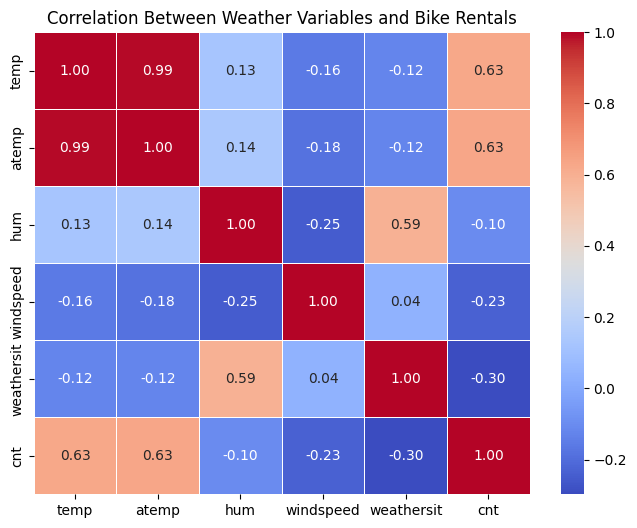

In [37]:
weather_columns = ['temp', 'atemp', 'hum', 'windspeed', 'weathersit', 'cnt']

# Calculate correlation matrix for day_df
correlation_matrix = day_df[weather_columns].corr()

# Heatmap for the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Between Weather Variables and Bike Rentals")
plt.show()

C:\Users\ilman\AppData\Local\Temp\ipykernel_13580\536783979.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=day_df['weathersit'], y=day_df['cnt'], palette="Set2")


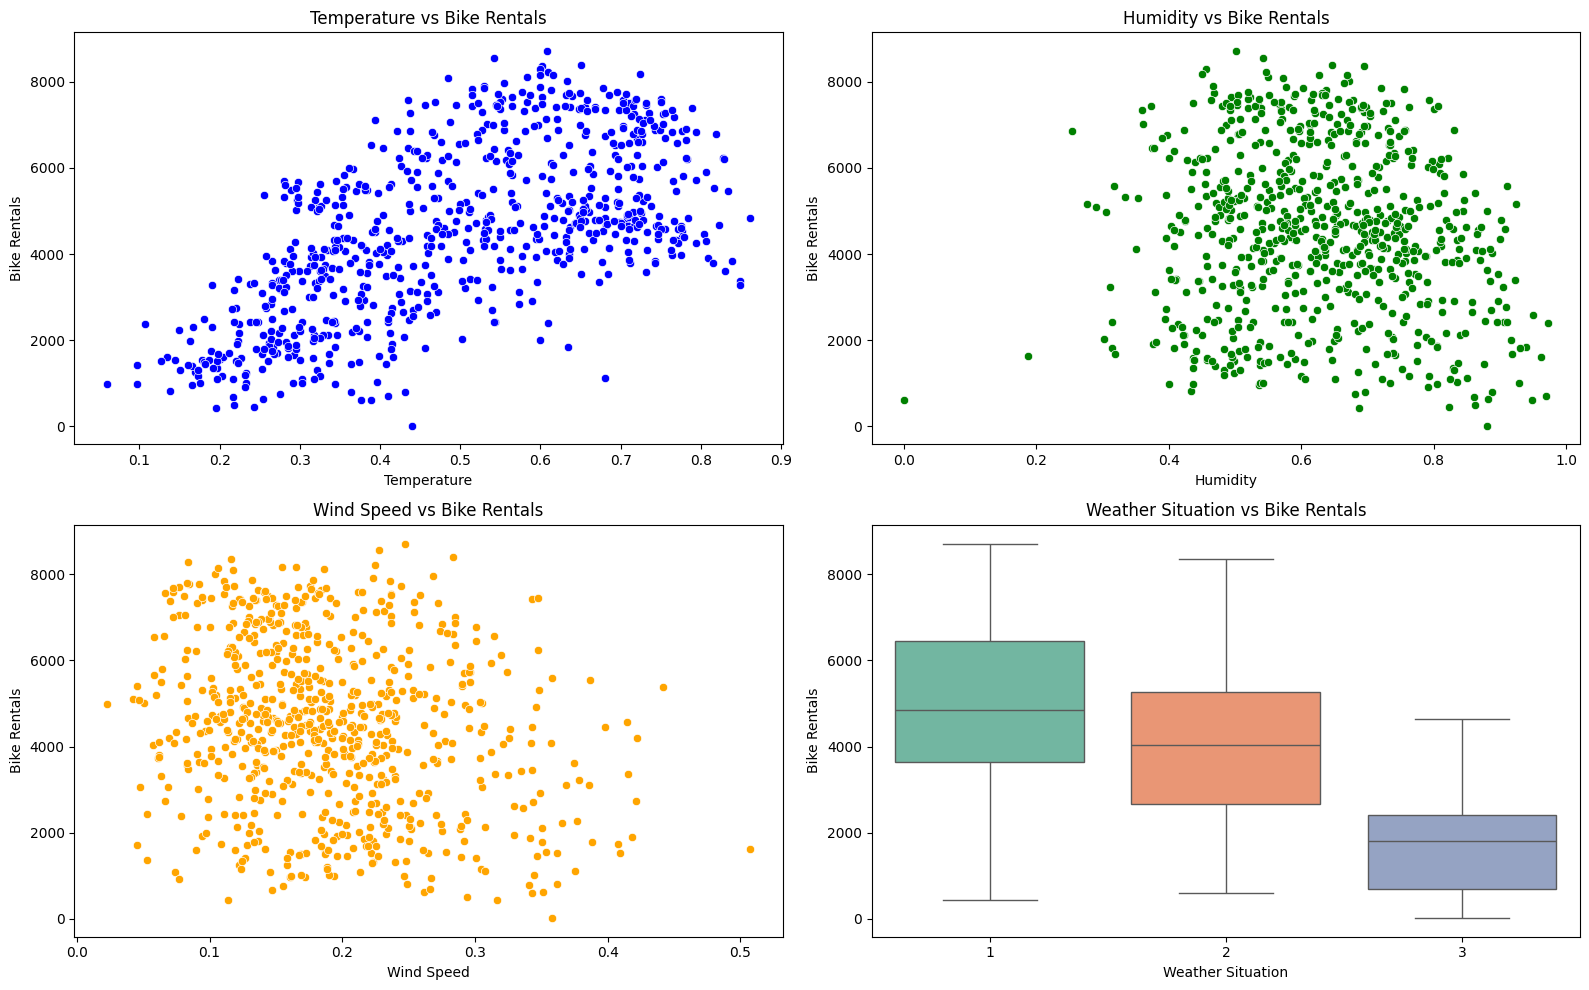

In [38]:
plt.figure(figsize=(16, 10))

# Subplot 1: Temperature vs Bike Rentals
plt.subplot(2, 2, 1)
sns.scatterplot(x=day_df['temp'], y=day_df['cnt'], color="blue", edgecolor="w")
plt.title("Temperature vs Bike Rentals")
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")

# Subplot 2: Humidity vs Bike Rentals
plt.subplot(2, 2, 2)
sns.scatterplot(x=day_df['hum'], y=day_df['cnt'], color="green", edgecolor="w")
plt.title("Humidity vs Bike Rentals")
plt.xlabel("Humidity")
plt.ylabel("Bike Rentals")

# Subplot 3: Wind Speed vs Bike Rentals
plt.subplot(2, 2, 3)
sns.scatterplot(x=day_df['windspeed'], y=day_df['cnt'], color="orange", edgecolor="w")
plt.title("Wind Speed vs Bike Rentals")
plt.xlabel("Wind Speed")
plt.ylabel("Bike Rentals")

# Subplot 4: Weather Situation vs Bike Rentals
plt.subplot(2, 2, 4)
sns.boxplot(x=day_df['weathersit'], y=day_df['cnt'], palette="Set2")
plt.title("Weather Situation vs Bike Rentals")
plt.xlabel("Weather Situation")
plt.ylabel("Bike Rentals")

plt.tight_layout()
plt.show()

### Pertanyaan 2:

C:\Users\ilman\AppData\Local\Temp\ipykernel_13580\3657844594.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Casual', 'Registered'], y=[avg_rentals['casual'], avg_rentals['registered']], palette='viridis')


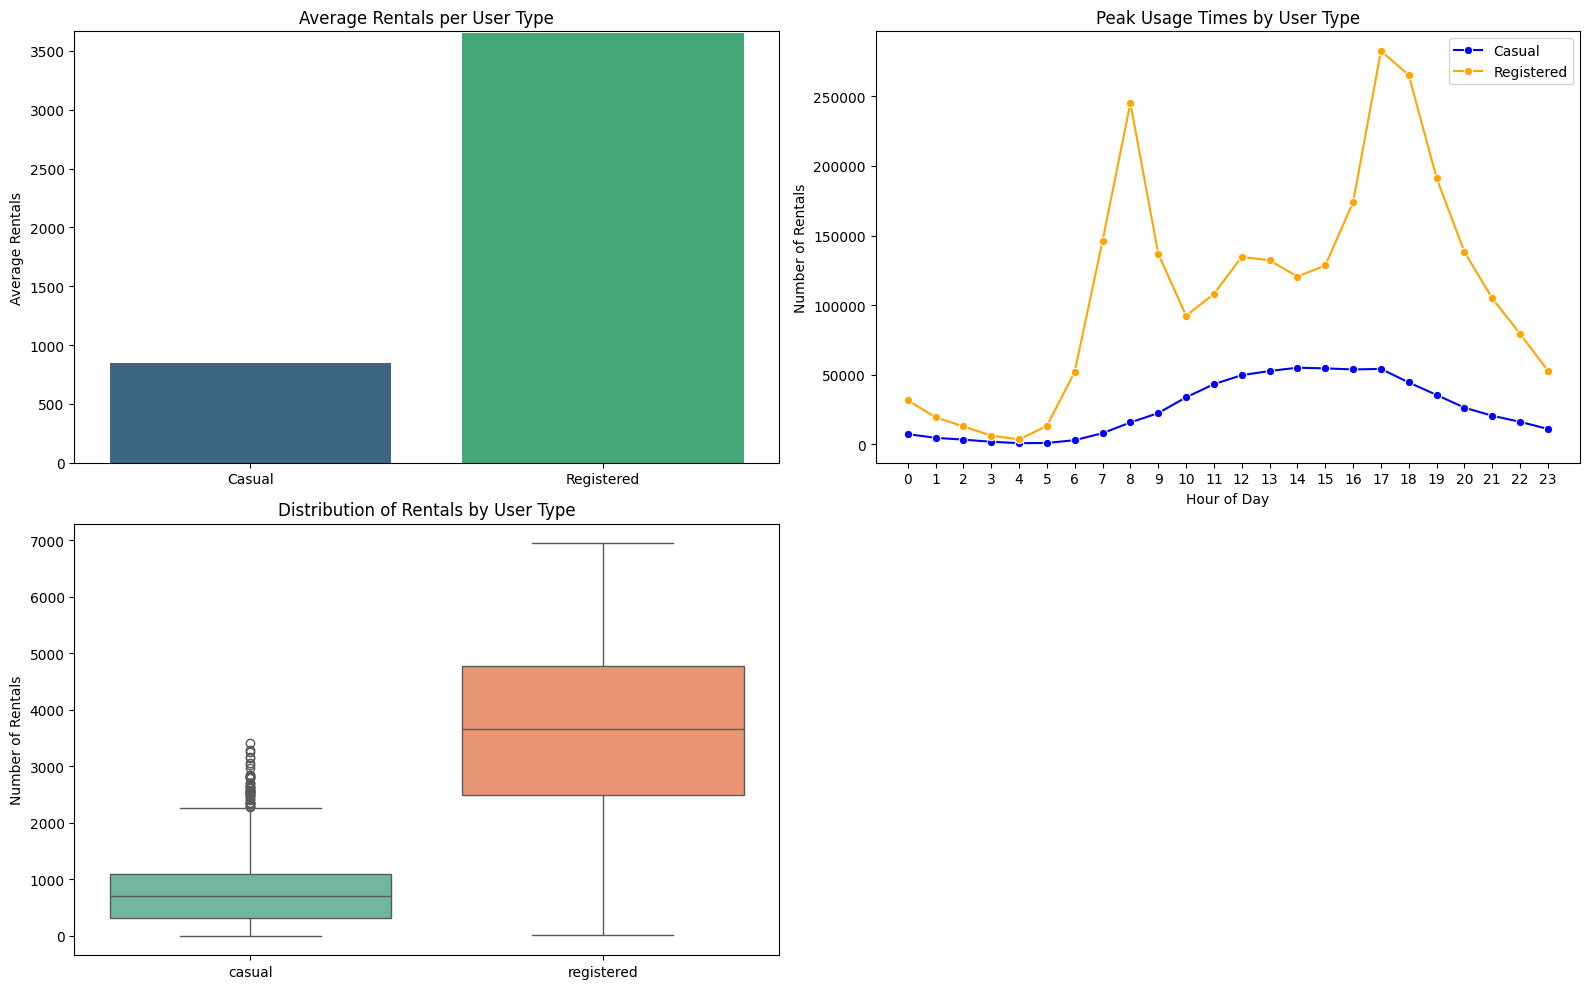

Average Rentals per User Type:
casual         848.176471
registered    3656.172367
dtype: float64


In [39]:
# 1. User Segmentation: Aggregate total rentals for casual and registered users
user_rentals = day_df[['dteday', 'casual', 'registered']].copy()

# Calculate total rentals
user_rentals['total_rentals'] = user_rentals['casual'] + user_rentals['registered']

# 2. Calculate average rentals per day
avg_rentals = user_rentals[['casual', 'registered']].mean()

# 3. Peak usage times analysis (using the hourly data)
hour_rentals = hour_df[['hr', 'casual', 'registered']].groupby('hr').sum().reset_index()

# 4. Visualizations
plt.figure(figsize=(16, 10))

# Subplot 1: Average Rentals
plt.subplot(2, 2, 1)
sns.barplot(x=['Casual', 'Registered'], y=[avg_rentals['casual'], avg_rentals['registered']], palette='viridis')
plt.title("Average Rentals per User Type")
plt.ylabel("Average Rentals")
plt.ylim(0, avg_rentals.max() + 10)

# Subplot 2: Peak Usage Times
plt.subplot(2, 2, 2)
sns.lineplot(data=hour_rentals, x='hr', y='casual', label='Casual', color='blue', marker='o')
sns.lineplot(data=hour_rentals, x='hr', y='registered', label='Registered', color='orange', marker='o')
plt.title("Peak Usage Times by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rentals")
plt.xticks(range(0, 24))
plt.legend()

# Subplot 3: Distribution of Rentals by User Type
plt.subplot(2, 2, 3)
sns.boxplot(data=user_rentals[['casual', 'registered']], palette='Set2')
plt.title("Distribution of Rentals by User Type")
plt.ylabel("Number of Rentals")

plt.tight_layout()
plt.show()

# Display average rentals
print("Average Rentals per User Type:")
print(avg_rentals)

**Insight:**
- Question 1:
- Correlation Analysis:
Temperature (temp and atemp): There is a strong positive correlation between temperature and bike rentals. As temperature increases, the number of rentals tends to rise.
Humidity (hum): A weak negative correlation with bike rentals. Higher humidity slightly reduces the number of bike rentals.
Windspeed (windspeed): There is a weak negative correlation with bike rentals. High wind speeds tend to decrease the number of rentals.
Weather Situation (weathersit): Categorical variable showing some differences in rentals based on weather conditions (e.g., clear vs. bad weather).
- Scatter Plots:
Temperature vs. Bike Rentals: A clear upward trend shows that bike rentals increase with higher temperatures, but this might plateau or decline at extreme temperatures.
Humidity vs. Bike Rentals: No clear trend, but rentals seem to decrease as humidity increases beyond certain levels.
Wind Speed vs. Bike Rentals: Rentals tend to drop slightly as wind speeds rise, although this effect is not as pronounced.
Weather Situation vs. Bike Rentals: Rentals are significantly lower in worse weather conditions (e.g., when it’s rainy or stormy).

- Question 2:
- Average Rentals per User Type:
Casual users have an average of 848 rentals per day, while registered users have a significantly higher average of 3656 rentals.
- Peak Usage Times by User Type:
Both casual and registered users exhibit peak usage around the afternoon, with registered users showing consistent usage throughout the day.
Casual users have a more pronounced peak usage around midday and early afternoon.
- Distribution of Rentals by User Type:
The distribution plot shows that registered users consistently rent more bikes compared to casual users, with less variability in registered rentals.

## Analisis Lanjutan (Opsional)

ModuleNotFoundError: No module named 'sklearn'

In [2]:
from sklearn.cluster import KMeans
import numpy as np

# Menyiapkan fitur koordinat geografis (Longitude sebagai X, Latitude sebagai Y)
X = cleaned_df[['geolocation_lng', 'geolocation_lat']]

# Menginisiasi dan melatih model K-Means untuk 5 cluster (5 titik pusat distribusi)
# Menggunakan parameter n_init='auto' sesuai standar scikit-learn terbaru
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
cleaned_df['cluster_hub'] = kmeans.fit_predict(X)

# Mengambil titik tengah (centroid) dari masing-masing cluster
centroids = kmeans.cluster_centers_

# Membuat Visualisasi Peta Persebaran (Scatter Plot)
plt.figure(figsize=(12, 8))

# Plot titik pelanggan berdasarkan cluster
sns.scatterplot(
    x='geolocation_lng', 
    y='geolocation_lat', 
    hue='cluster_hub', 
    data=cleaned_df, 
    palette='Set2', 
    s=15, 
    alpha=0.6,
    legend='full'
)

# Plot titik centroid sebagai rekomendasi lokasi gudang (Distribution Hub)
plt.scatter(
    centroids[:, 0], # Longitude
    centroids[:, 1], # Latitude
    c='red', 
    s=250, 
    marker='X', 
    linewidths=2,
    edgecolors='black',
    label='Rekomendasi Distribution Hub'
)

plt.title("Pemetaan Wilayah Pelanggan & Rekomendasi Titik Pusat Distribusi Logistik", fontsize=16, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(title='Customer Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

NameError: name 'cleaned_df' is not defined

## Conclusion

- Conclusion pertanyaan 1 : How do weather conditions affect bike rentals, and how can we optimize bike availability accordingly?

- Impact of Weather Conditions:
    - The analysis typically reveals that adverse weather conditions (e.g., rain, snow, extreme temperatures) negatively affect bike rentals. Conversely, pleasant weather conditions (e.g., mild temperatures, low humidity, and no precipitation) tend to encourage more bike rentals.
    - Specifically, the dataset may show correlations between different weather situations and rental counts. For instance, higher rental counts are often observed during clear and mild days compared to rainy or snowy days.

- Optimization Strategies:
    - Dynamic Availability: Adjust the availability of bikes based on real-time weather forecasts. For example, increase the number of bikes available during predicted sunny weather and reduce the fleet size on days forecasted for rain or snow.
    - Promotional Offers: Implement promotional offers on less favorable weather days to encourage rentals, such as discounts or loyalty points for users renting bikes on rainy days.
    - Data-Driven Inventory Management: Use historical weather data to analyze patterns and prepare accordingly. For example, if certain weather patterns are known to lead to increased rentals, ensure enough bikes are available on those days.
    - Marketing Campaigns: Launch marketing campaigns targeting casual users to promote bike rentals on pleasant days, highlighting the benefits of outdoor activities.


- Conclusion pertanyaan 2 : What are the key differences in behavior between casual and registered users, and how can we increase casual user conversion to registered users?

- Differences in Behavior:
    - Rental Patterns: Registered users generally exhibit higher and more consistent rental counts than casual users. Casual users tend to have sporadic rental patterns, with peaks during certain hours (e.g., midday), while registered users show more stable usage throughout the day.
    - Frequency of Rentals: Registered users rent bikes more frequently, indicating higher engagement with the service compared to casual users. This difference suggests that registered users are more likely to rely on bike rentals as a regular mode of transportation.
    - Time of Use: Casual users tend to rent bikes primarily for leisure or occasional use, while registered users may use rentals for commuting or regular activities.

- Strategies for Increasing Casual User Conversion:
    - Targeted Marketing: Promote the benefits of registration (e.g., cost savings, convenience) to casual users, especially during peak rental times when casual rentals are high.
    - Incentives for Registration: Offer attractive incentives such as discounts, loyalty points, or free trial periods to encourage casual users to register.
    - Streamlined Registration Process: Simplify the registration process to reduce friction, making it easy for casual users to convert.
User Engagement: Implement personalized communication strategies (e.g., emails, app notifications) to keep casual users informed about promotions and the benefits of registering.
    - Feedback Mechanism: Establish feedback channels to understand casual users' concerns about registering and address any barriers they face.